*This notebook batch-tests Ambivision No_Direction image and txt pairs.*

# Ambivision Neurips No_Direction — model answers vs bounding-box animals

In [1]:
# Install Python packages including kagglehub.
!pip3 install -q kagglehub torch torchvision transformers pillow


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
# Import libraries for files, images, and models.
import re
from pathlib import Path

import kagglehub
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import vit_b_16, ViT_B_16_Weights
from transformers import CLIPModel, CLIPProcessor

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.3) or chardet (7.0.1)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Download Ambivision and list all image txt pairs in No_Direction.
path = kagglehub.dataset_download("anonymac12i3/ambivision")
root = Path(path)
sub = root / "Neurips_collection" / "No_Direction"
if not sub.is_dir():
    for p in root.rglob("No_Direction"):
        if p.is_dir():
            sub = p
            break
print("No_Direction:", sub)
images = sorted(sub.glob("*.jpg")) + sorted(sub.glob("*.JPG")) + sorted(sub.glob("*.png")) + sorted(sub.glob("*.PNG"))
paired = [img for img in images if img.with_suffix(".txt").is_file()]
print("num images total:", len(images))
print("num image+txt pairs:", len(paired))
print("num skipped (missing txt):", len(images) - len(paired))


No_Direction: /Users/anikapandey/.cache/kagglehub/datasets/anonymac12i3/ambivision/versions/10/Ambivision/Neurips_collection/No_Direction
num images total: 203
num image+txt pairs: 200
num skipped (missing txt): 3


In [4]:
# Functions to parse bounding box animal names from txt files.
def parse_box_animals(txt_path):
    a1 = a2 = None
    for line in open(txt_path, encoding="utf-8", errors="replace"):
        line = line.strip()
        if line.startswith("boundingbox1"):
            m = re.match(r"boundingbox1\s+(.+)", line, re.I)
            if m:
                a1 = m.group(1).strip()
        elif line.startswith("boundingbox2"):
            m = re.match(r"boundingbox2\s+(.+)", line, re.I)
            if m:
                a2 = m.group(1).strip()
    return a1, a2


def norm_animal(s):
    if not s:
        return ""
    s = s.lower().strip()
    if s == "pidgeon":
        s = "pigeon"
    return s


def tokens(s):
    s = re.sub(r"[^a-z0-9]+", " ", s.lower())
    return [t for t in s.split() if len(t) > 1]


def pred_matches_animal(pred_label, animal):
    animal = norm_animal(animal)
    if not animal:
        return False
    p = pred_label.lower()
    if animal in p:
        return True
    for part in p.split(","):
        part = part.strip()
        if animal in part or part in animal:
            return True
    ptoks, atoks = set(tokens(p)), set(tokens(animal))
    if atoks and atoks <= ptoks:
        return True
    for t in atoks:
        if t in ptoks:
            return True
    return False

In [5]:
# Set device and load ResNet, EfficientNet, ViT, and CLIP.
device = "cuda" if torch.cuda.is_available() else "cpu"

res_w = ResNet50_Weights.DEFAULT
resnet = resnet50(weights=res_w).to(device).eval()
res_pre = res_w.transforms()
imagenet_classes = list(res_w.meta["categories"])

eff_w = EfficientNet_B0_Weights.DEFAULT
effnet = efficientnet_b0(weights=eff_w).to(device).eval()
eff_pre = eff_w.transforms()

vit_w = ViT_B_16_Weights.DEFAULT
vit = vit_b_16(weights=vit_w).to(device).eval()
vit_pre = vit_w.transforms()

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device).eval()
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [6]:
# Precompute CLIP text embeddings for full ImageNet word list.
clip_texts = [f"a photo of a {c}" for c in imagenet_classes]
chunk = 256
with torch.no_grad():
    te = []
    for i in range(0, len(clip_texts), chunk):
        batch = clip_texts[i : i + chunk]
        inp = clip_processor(text=batch, return_tensors="pt", padding=True, truncation=True).to(device)
        f = clip_model.get_text_features(**inp)
        f = F.normalize(f, dim=-1)
        te.append(f.cpu())
    clip_text_emb = torch.cat(te, dim=0).to(device)


@torch.no_grad()
def clip_imagenet_topk(pil_img, k=5):
    inp = clip_processor(images=pil_img, return_tensors="pt").to(device)
    imf = clip_model.get_image_features(**inp)
    imf = F.normalize(imf, dim=-1)
    sim = (imf @ clip_text_emb.T).squeeze(0)
    idx = sim.topk(k=min(k, sim.shape[0])).indices.tolist()
    return [imagenet_classes[j] for j in idx]


@torch.no_grad()
def torch_topk(model, preprocess, pil_img, k=5):
    x = preprocess(pil_img.convert("RGB")).unsqueeze(0).to(device)
    logits = model(x)
    idx = logits.squeeze(0).topk(k=min(k, logits.shape[1])).indices.tolist()
    return [imagenet_classes[j] for j in idx]


In [7]:
# Metrics helpers for top-k hits and two-choice summaries.
def best_rank_for_pair(pred_list, a1, a2):
    r = None
    for i, p in enumerate(pred_list, start=1):
        if pred_matches_animal(p, a1) or pred_matches_animal(p, a2):
            r = i
            break
    return r


def eval_run(name, pred_lists, animals1, animals2, n):
    top1_ok = 0
    top5_ok = 0
    top1_hit1 = 0
    top1_hit2 = 0
    rank_counts = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
    for plist, a1, a2 in zip(pred_lists, animals1, animals2):
        p1 = plist[0]
        m1 = pred_matches_animal(p1, a1)
        m2 = pred_matches_animal(p1, a2)
        if m1 or m2:
            top1_ok += 1
        if m1:
            top1_hit1 += 1
        if m2:
            top1_hit2 += 1
        r = best_rank_for_pair(plist[:5], a1, a2)
        if r is not None:
            top5_ok += 1
            rank_counts[r] += 1
    print(name)
    print("  n", n)
    print("  overall_accuracy_top1", round(top1_ok / n, 4) if n else 0.0)
    print("  overall_accuracy_top5", round(top5_ok / n, 4) if n else 0.0)
    print("  rate_top1_predicted_box1_animal", round(top1_hit1 / n, 4) if n else 0.0)
    print("  rate_top1_predicted_box2_animal", round(top1_hit2 / n, 4) if n else 0.0)
    for r in [1, 2, 3, 4, 5]:
        print(f"  correct_at_rank_{r}", round(rank_counts[r] / n, 4) if n else 0.0)


In [8]:
# Loop over every paired image and store top-5 predictions per model.
rows = []
for img in paired:
    txt = img.with_suffix(".txt")
    a1, a2 = parse_box_animals(txt)
    if not a1 or not a2:
        continue
    im = Image.open(img).convert("RGB")
    pr = torch_topk(resnet, res_pre, im, k=5)
    pe = torch_topk(effnet, eff_pre, im, k=5)
    pv = torch_topk(vit, vit_pre, im, k=5)
    pc = clip_imagenet_topk(im, k=5)
    rows.append({"image": img.name, "a1": a1, "a2": a2, "ResNet50": pr, "EfficientNet-B0": pe, "ViT-B/16": pv, "CLIP": pc})

n = len(rows)
print("evaluated", n, "pairs")
if n == 0:
    raise RuntimeError("no valid image+txt pairs under No_Direction")

a1s = [r["a1"] for r in rows]
a2s = [r["a2"] for r in rows]

for key in ["ResNet50", "EfficientNet-B0", "ViT-B/16", "CLIP"]:
    pred_lists = [r[key] for r in rows]
    eval_run(key, pred_lists, a1s, a2s, n)


evaluated 200 pairs
ResNet50
  n 200
  overall_accuracy_top1 0.115
  overall_accuracy_top5 0.23
  rate_top1_predicted_box1_animal 0.085
  rate_top1_predicted_box2_animal 0.03
  correct_at_rank_1 0.115
  correct_at_rank_2 0.045
  correct_at_rank_3 0.035
  correct_at_rank_4 0.015
  correct_at_rank_5 0.02
EfficientNet-B0
  n 200
  overall_accuracy_top1 0.075
  overall_accuracy_top5 0.15
  rate_top1_predicted_box1_animal 0.055
  rate_top1_predicted_box2_animal 0.02
  correct_at_rank_1 0.075
  correct_at_rank_2 0.01
  correct_at_rank_3 0.01
  correct_at_rank_4 0.02
  correct_at_rank_5 0.035
ViT-B/16
  n 200
  overall_accuracy_top1 0.12
  overall_accuracy_top5 0.27
  rate_top1_predicted_box1_animal 0.105
  rate_top1_predicted_box2_animal 0.015
  correct_at_rank_1 0.12
  correct_at_rank_2 0.065
  correct_at_rank_3 0.025
  correct_at_rank_4 0.04
  correct_at_rank_5 0.02
CLIP
  n 200
  overall_accuracy_top1 0.38
  overall_accuracy_top5 0.7
  rate_top1_predicted_box1_animal 0.29
  rate_top1_pred

In [9]:
# Helper to score ImageNet logits against just the two txt animals.
@torch.no_grad()
def torch_two_choice(model, preprocess, pil_img, a1, a2):
    x = preprocess(pil_img.convert("RGB")).unsqueeze(0).to(device)
    probs = model(x).softmax(dim=1).squeeze(0)
    score1 = 0.0
    score2 = 0.0
    for i, c in enumerate(imagenet_classes):
        if pred_matches_animal(c, a1):
            score1 += float(probs[i])
        if pred_matches_animal(c, a2):
            score2 += float(probs[i])
    if score1 == 0.0 and score2 == 0.0:
        return "unknown", 0.0, 0.0
    return ("box1" if score1 >= score2 else "box2"), score1, score2


@torch.no_grad()
def clip_two_choice(pil_img, a1, a2):
    prompts = [f"a photo of a {a1}", f"a photo of a {a2}"]
    inp = clip_processor(text=prompts, images=pil_img, return_tensors="pt", padding=True).to(device)
    logits = clip_model(**inp).logits_per_image.squeeze(0)
    probs = logits.softmax(dim=0)
    return ("box1" if probs[0] >= probs[1] else "box2"), float(probs[0]), float(probs[1])


In [10]:
# Print two-choice box1 versus box2 rates for each backbone.
def eval_two_choice(name, picks, n):
    box1 = sum(1 for p in picks if p == "box1")
    box2 = sum(1 for p in picks if p == "box2")
    unk = sum(1 for p in picks if p == "unknown")
    den = max(n - unk, 1)
    print(name)
    print("  picked_box1_rate", round(box1 / den, 4))
    print("  picked_box2_rate", round(box2 / den, 4))
    print("  unknown_rate", round(unk / n, 4) if n else 0.0)


picks_r, picks_e, picks_v, picks_c = [], [], [], []
for r in rows:
    img = Image.open(sub / r["image"]).convert("RGB")
    a1, a2 = r["a1"], r["a2"]
    pr, _, _ = torch_two_choice(resnet, res_pre, img, a1, a2)
    pe, _, _ = torch_two_choice(effnet, eff_pre, img, a1, a2)
    pv, _, _ = torch_two_choice(vit, vit_pre, img, a1, a2)
    pc, _, _ = clip_two_choice(img, a1, a2)
    picks_r.append(pr)
    picks_e.append(pe)
    picks_v.append(pv)
    picks_c.append(pc)

print("two-choice box preference rates")
eval_two_choice("ResNet50", picks_r, n)
eval_two_choice("EfficientNet-B0", picks_e, n)
eval_two_choice("ViT-B/16", picks_v, n)
eval_two_choice("CLIP", picks_c, n)


two-choice box preference rates
ResNet50
  picked_box1_rate 0.6263
  picked_box2_rate 0.3737
  unknown_rate 0.01
EfficientNet-B0
  picked_box1_rate 0.5404
  picked_box2_rate 0.4596
  unknown_rate 0.01
ViT-B/16
  picked_box1_rate 0.6717
  picked_box2_rate 0.3283
  unknown_rate 0.01
CLIP
  picked_box1_rate 0.665
  picked_box2_rate 0.335
  unknown_rate 0.0


image: badgerpidgeon.jpg
categories: box1=badger box2=pidgeon

no-choice top5 (correct if either animal appears)
ResNet50 top1= mask top5_hit= False rank= None
EfficientNet-B0 top1= car wheel top5_hit= False rank= None
ViT-B/16 top1= papillon top5_hit= False rank= None
CLIP top1= badger top5_hit= True rank= 1

two-choice pick (box1 vs box2)
ResNet50 box1 0.0007 0.0
EfficientNet-B0 box1 0.0001 0.0
ViT-B/16 box1 0.0001 0.0
CLIP box1 1.0 0.0


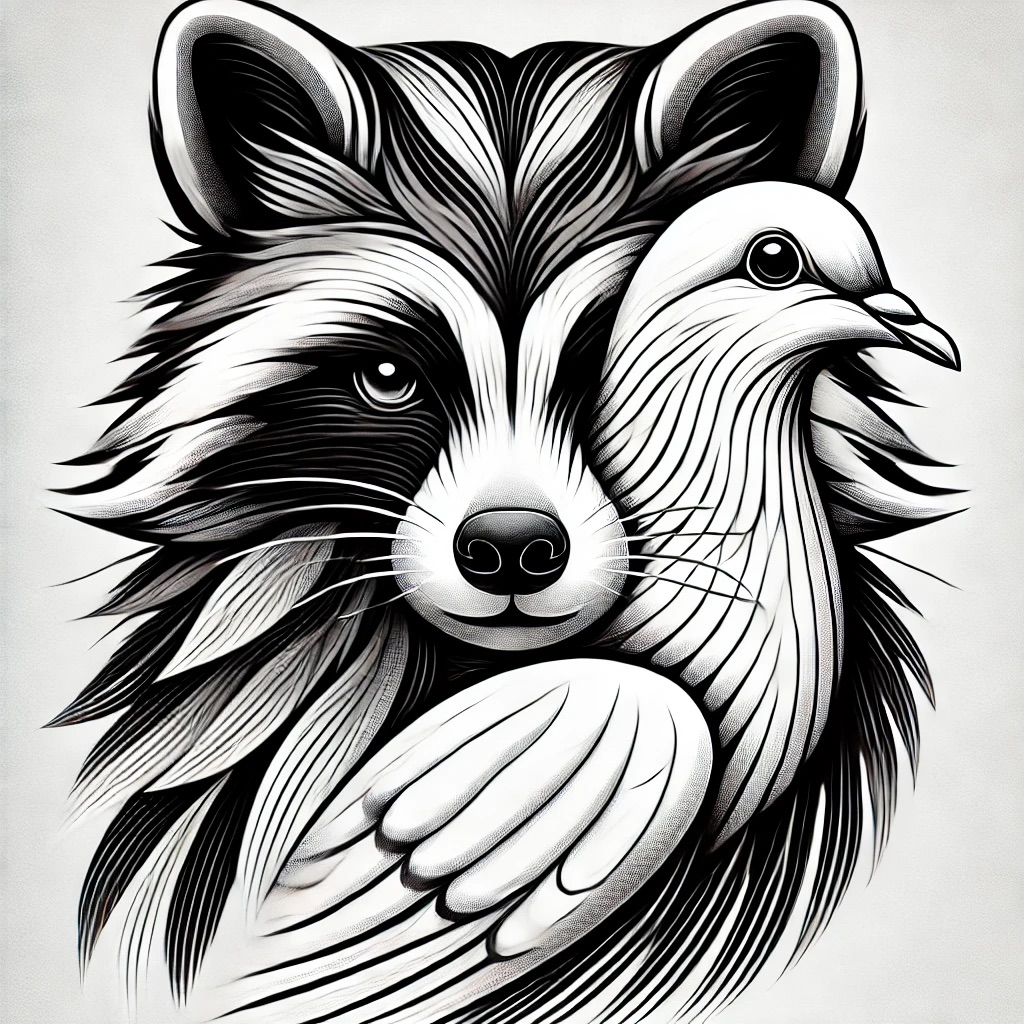

In [11]:
# Print a detailed walkthrough for the first image in the list.
demo = rows[0]
img = Image.open(sub / demo["image"]).convert("RGB")
a1, a2 = demo["a1"], demo["a2"]
print("image:", demo["image"])
print("categories:", "box1=" + a1, "box2=" + a2)
print()

print("no-choice top5 (correct if either animal appears)")
for model_name in ["ResNet50", "EfficientNet-B0", "ViT-B/16", "CLIP"]:
    top5 = demo[model_name]
    rank = best_rank_for_pair(top5, a1, a2)
    print(model_name, "top1=", top5[0], "top5_hit=", rank is not None, "rank=", rank)

print()
print("two-choice pick (box1 vs box2)")
pr, sr1, sr2 = torch_two_choice(resnet, res_pre, img, a1, a2)
pe, se1, se2 = torch_two_choice(effnet, eff_pre, img, a1, a2)
pv, sv1, sv2 = torch_two_choice(vit, vit_pre, img, a1, a2)
pc, sc1, sc2 = clip_two_choice(img, a1, a2)
print("ResNet50", pr, round(sr1, 4), round(sr2, 4))
print("EfficientNet-B0", pe, round(se1, 4), round(se2, 4))
print("ViT-B/16", pv, round(sv1, 4), round(sv2, 4))
print("CLIP", pc, round(sc1, 4), round(sc2, 4))
img
